In [1]:
import numpy as np
import seaborn as sns
from scipy.io import wavfile

In [2]:
samp_rate,data = wavfile.read("mensaje.wav")
length = data.shape[0] / samp_rate

In [3]:
l = data[:,0]
r = data[:, 1]

<Axes: >

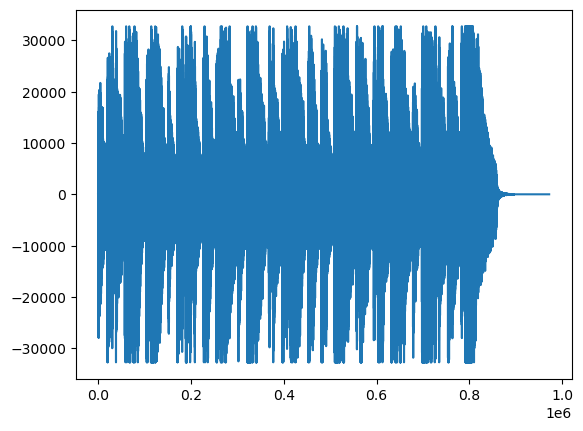

In [4]:
sns.lineplot(l)

<Axes: >

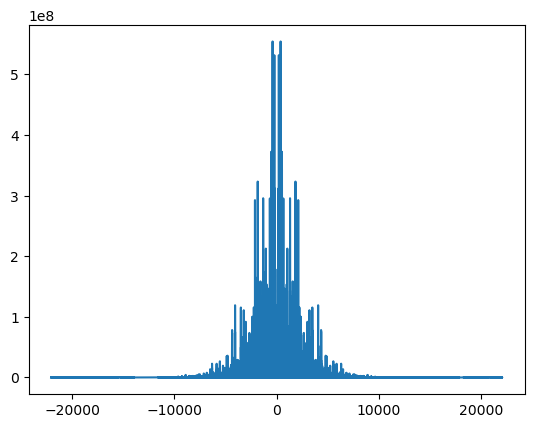

In [5]:
fft = np.abs(np.fft.fft(l))
bwidth = fft.size//2
freqs = np.roll(np.arange(-bwidth, bwidth), bwidth) * (samp_rate/(2*bwidth))
sns.lineplot(y=fft, x=freqs)

# Peaks detection

In [6]:
from scipy.signal import find_peaks

def find_peaks(s, n=1):
    
    # Next < Curr and Last < Curr 
    peaks = np.where(
        (s[1:] > s[:-1])[:-1]
        &
        (s[1:-1]>s[2:])
    )[0]
    
    # +1 (compared arrays are shifted 1)
    peaks += 1
    
    if n == 1:
        return peaks

    return peaks[find_peaks(s[peaks], n=n-1)]

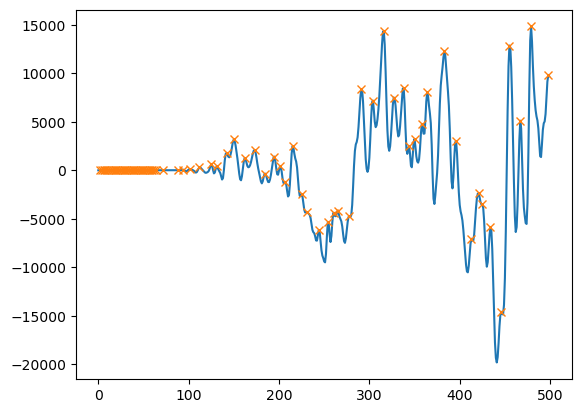

In [7]:
import matplotlib.pyplot as plt

t_peaks = find_peaks(l, n=1)

plt.plot(l[:500])
plt.plot(t_peaks[:75], l[t_peaks][:75], "x")

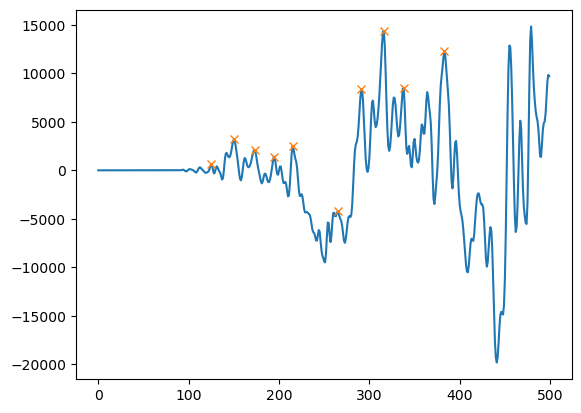

In [8]:
t2_peaks = find_peaks(l, n=2)

plt.plot(l[:500])
plt.plot(t2_peaks[:10], l[t2_peaks][:10], "x")

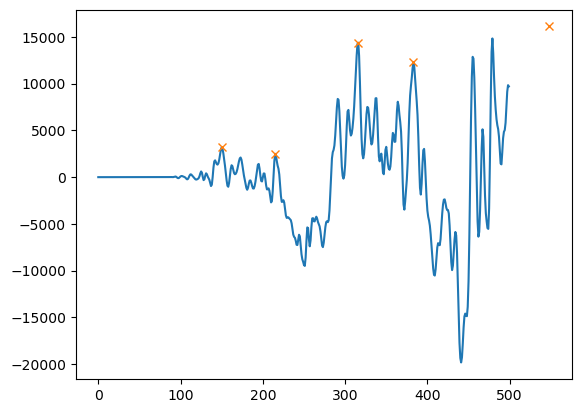

In [9]:
t3_peaks = find_peaks(l, n=3)

plt.plot(l[:500])
plt.plot(t3_peaks[:5], l[t3_peaks][:5], "x")

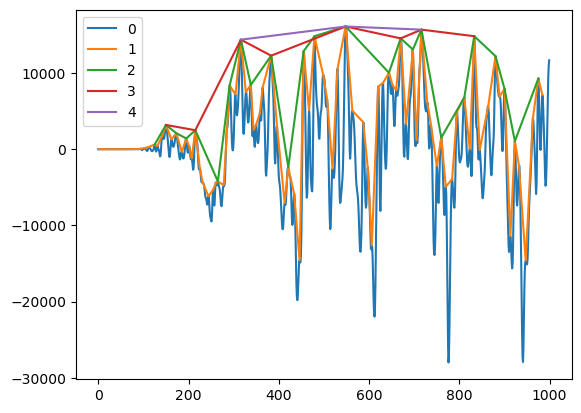

In [10]:
plt.plot(l[:1000])
for i in range(1,5):
    p = find_peaks(l[:1000], n=i)
    plt.plot(p, l[p])
    plt.legend(range(5))

# Find peaks rate

~ onsets

In [11]:
compas = 4
similar_rate = 1 / compas

In [34]:
rates = []
def get_rate(l, n=1):
    peaks = find_peaks(l, n=n)
    # Distance between peaks
    rate = peaks[1:] - peaks[:-1]
    return rate

rates = []
for i in range(1, 10):
    rate = get_rate(l, n=i)/samp_rate
    rates.append(np.abs(rate.mean() - similar_rate))
    print(i, rate.mean(), np.abs(rate.mean() - similar_rate))
    
rates = np.array(rates)
best_rate = rates[~np.isnan(rates)].argmin()
print(best_rate_n) # secondsb

1 0.000363691395417182 0.24963630860458283
2 0.0013619214475745526 0.24863807855242545
3 0.00400577938090785 0.24599422061909215
4 0.012233356416418864 0.23776664358358113
5 0.04196489566290651 0.2080351043370935
6 0.15164604424446942 0.09835395575553058
7 0.4871361157075442 0.23713611570754423
8 1.594018140589569 1.344018140589569
9 nan nan
0


/tmp/ipykernel_8175/3874903672.py:11: RuntimeWarning: Mean of empty slice.
  rates.append(np.abs(rate.mean() - similar_rate))
/usr/lib/python3/dist-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_8175/3874903672.py:12: RuntimeWarning: Mean of empty slice.
  print(i, rate.mean(), np.abs(rate.mean() - similar_rate))


In [35]:
window_size = int(rates[best_rate_n] * samp_rate)
window_size # samps

11008

# Find notes

~compas

FFT indexes meaning:
    

i_percent = (i / (fft.size/2)) # Goes from -100% to 100% 

max_f = samp_rate / 2

In [36]:
def fft_freqs(fft, samp_rate):
    
    max_samp = fft.size//2
    samps = np.roll(np.arange(-max_samp, max_samp + (1 if fft.size % 2 else 0)), fft.size//2) 
    
    return samps * (samp_rate/2) * (1 / max_samp)

def i2f(i, fft, samp_rate):
    
    max_samp = fft.size//2
    samps = np.roll(np.arange(-max_samp, max_samp + (1 if fft.size % 2 else 0)), fft.size//2) 
    
    return i * (samp_rate/2) * (1 / max_samp)

def f2i(f, fft, samp_rate):
    max_samp = fft.size//2
    return int((f / (samp_rate/2)) * max_samp)

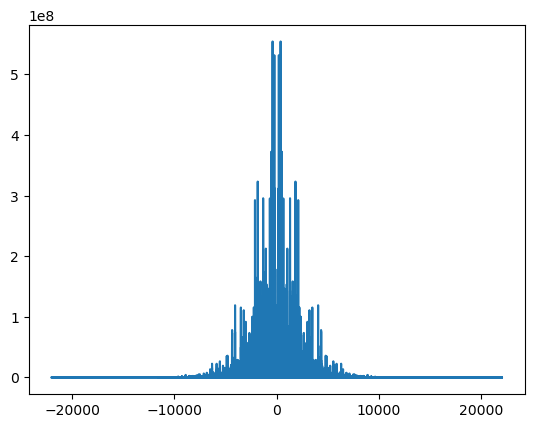

In [37]:
fft = np.abs(np.fft.fft(l))

max_samp = fft.size//2

plt.plot(fft_freqs(fft, samp_rate), np.abs(fft))

In [38]:
ACORDES = {"C":  [261.63, 329.63, 392.00],   # C4, E4, G4
           "G":  [196.00, 246.94, 293.66],   # G3, B3, D4
           "Am": [220.00, 261.63, 329.63],   # A3, C4/(523.25 Hz), E4
           "F":  [174.61, 220.00, 130.81],   # F3, A3 (349.23 Hz), C3
}

In [39]:
max_freq = -1
min_freq = 20e3
for acorde in ACORDES:
    for freq in ACORDES[acorde]:
        max_freq = max(max_freq, freq)
        min_freq = min(min_freq, freq)

print(min_freq, max_freq)

130.81 392.0


In [40]:
# BPF (notes range)
min_freq_i = f2i(min_freq*0.8, fft, samp_rate)
max_freq_i = f2i(max_freq*1.25, fft, samp_rate)
min_freq_i, max_freq_i

(2306, 10800)

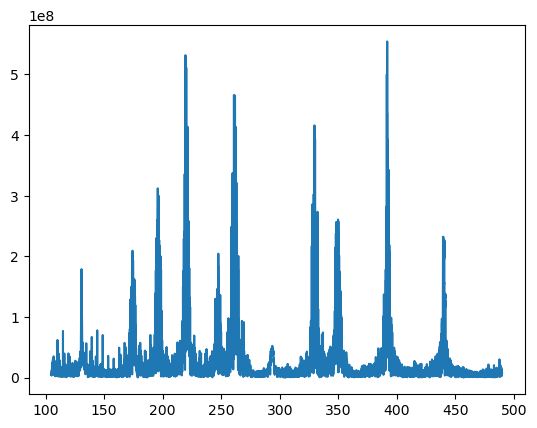

In [41]:
filtered = fft[min_freq_i:max_freq_i]
filtered_freqs = fft_freqs(fft, samp_rate)[min_freq_i:max_freq_i]
plt.plot(filtered_freqs, filtered)

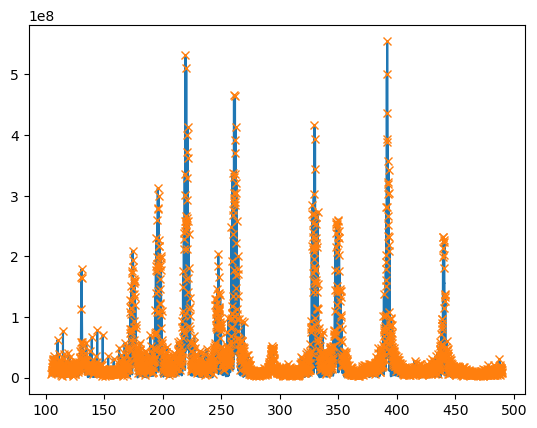

In [42]:
peaks = find_peaks(filtered, n=1)
plt.plot(filtered_freqs, filtered)
plt.plot(filtered_freqs[peaks], filtered[peaks], 'x')

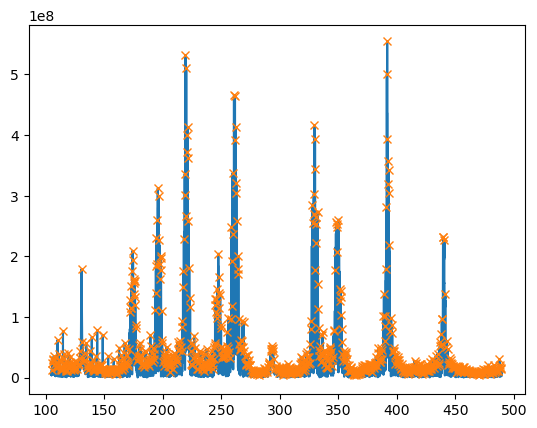

In [43]:
peaks = find_peaks(filtered, n=2)
plt.plot(filtered_freqs, filtered)
plt.plot(filtered_freqs[peaks], filtered[peaks], 'x')

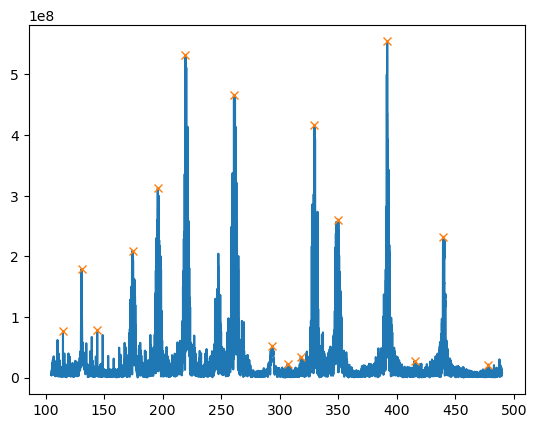

In [44]:
peaks = find_peaks(filtered, n=5)
plt.plot(filtered_freqs, filtered)
plt.plot(filtered_freqs[peaks], filtered[peaks], 'x')

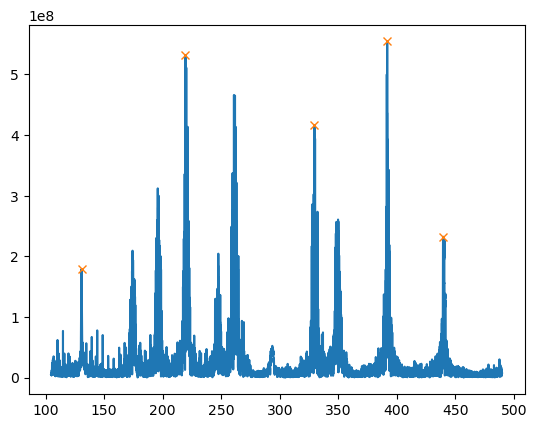

In [45]:
peaks = find_peaks(filtered, n=6)
plt.plot(filtered_freqs, filtered)
plt.plot(filtered_freqs[peaks], filtered[peaks], 'x')

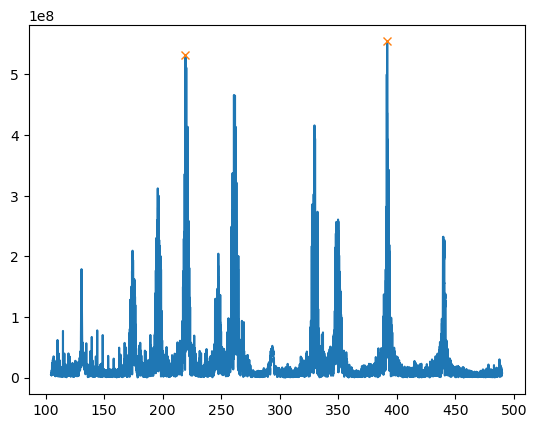

In [46]:
peaks = find_peaks(filtered, n=7)
plt.plot(filtered_freqs, filtered)
plt.plot(filtered_freqs[peaks], filtered[peaks], 'x')

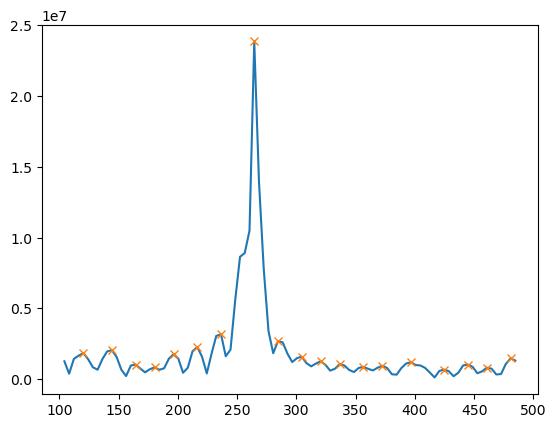

In [68]:
fft = np.abs(np.fft.fft(l[window_size:2*window_size]))

# BPF (notes range)
min_freq_i = f2i(min_freq*0.8, fft, samp_rate)
max_freq_i = f2i(max_freq*1.25, fft, samp_rate)
min_freq_i, max_freq_i

filtered = fft[min_freq_i:max_freq_i]
filtered_freqs = fft_freqs(fft, samp_rate)[min_freq_i:max_freq_i]

peaks = find_peaks(filtered, n=1)
plt.plot(filtered_freqs, filtered)
plt.plot(filtered_freqs[peaks], filtered[peaks], 'x')

In [69]:
n_for_one = int(np.log2(peaks.size)) - 1
n_for_one

3

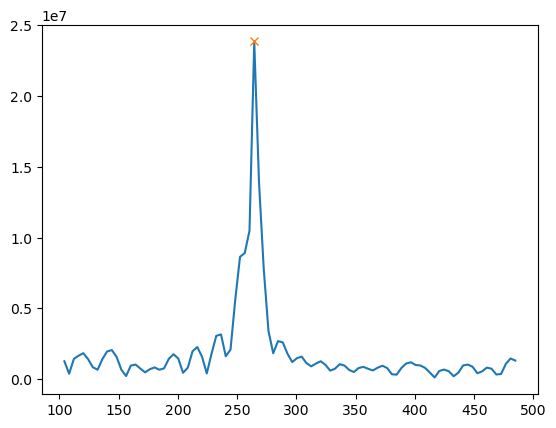

In [70]:
peaks = find_peaks(filtered, n=n_for_one)
plt.plot(filtered_freqs, filtered)
plt.plot(filtered_freqs[peaks], filtered[peaks], 'x')

In [71]:
windows = l.size // window_size
notes = []
for i in range(windows):
    chunk = l[(i+1)*window_size:(i+2)*window_size]
    
    fft = np.abs(np.fft.fft(chunk))
    freqs = fft_freqs(fft, samp_rate)

    min_freq_i = f2i(min_freq*0.8, fft, samp_rate)
    max_freq_i = f2i(max_freq*1.25, fft, samp_rate)

    filtered = fft[min_freq_i:max_freq_i]
    filtered_freqs = freqs[min_freq_i:max_freq_i]
    
    peaks = find_peaks(filtered, n=1)
    n_for_one = int(np.log2(peaks.size)) - 1
    peaks = find_peaks(filtered, n=n_for_one)
    
    notes.append(filtered_freqs[peaks])
    
notes

[array([264.40770349]),
 array([260.40152616, 436.67332849]),
 array([], dtype=float64),
 array([], dtype=float64),
 array([196.30268895]),
 array([248.38299419]),
 array([220.33975291]),
 array([292.45094477]),
 array([], dtype=float64),
 array([348.53742733]),
 array([348.53742733]),
 array([260.40152616]),
 array([260.40152616]),
 array([260.40152616, 348.53742733]),
 array([260.40152616]),
 array([], dtype=float64),
 array([260.40152616]),
 array([], dtype=float64),
 array([260.40152616, 332.51271802]),
 array([], dtype=float64),
 array([], dtype=float64),
 array([260.40152616]),
 array([248.38299419]),
 array([220.33975291]),
 array([260.40152616, 392.60537791]),
 array([260.40152616]),
 array([], dtype=float64),
 array([260.40152616]),
 array([176.27180233, 348.53742733]),
 array([220.33975291]),
 array([264.40770349, 344.53125   , 440.67950581]),
 array([260.40152616, 440.67950581]),
 array([], dtype=float64),
 array([172.265625  , 260.40152616]),
 array([], dtype=float64),
 arr

In [ ]:
perc = samps * (1 / max_samp)

plt.plot(perc, np.abs(fft))

In [ ]:
max_freq = samp_rate /2

freqs = perc * max_freq

plt.plot(freqs, np.abs(fft))

In [ ]:
@np.vectorize
def i2f(i, samp_rate, fft_size):
    max_samp = fft_size // 2
    perc = i / max_samp
    
    max_freq = samp_rate/2
    # bw is usually fft.size//2
    return perc * max_freq

@np.vectorize
def f2i(f, samp_rate, fft_size):
    
    max_freq = samp_rate/2
    perc = i / max_samp
    
    max_samp = fft_size // 2
    
    return int(perc * max_samp)

# Find notes from peaks rate

In [14]:
freq_range = 10e6
i_range = f2i(freq_range, samp_rate, window_size)

for i in range(windows):
    bw = window_size//2
    fft = np.fft.fft(l[(i+1)*bw:(i+2)*bw])
    freqs = np.roll(np.arange(-bw, bw+(1 if bw%2 else 0)), bw) * (samp_rate/(2*bw))

    print(freqs[np.abs(fft)[:max_i].argmax()])
    

NameError: name 'f2i' is not defined

In [ ]:
t = np.arange(0, 1, 1/samp_rate)
f = 440
s = np.sin(2*np.pi*t*f)

In [ ]:
fft = np.fft.fft(s[:1000])


In [ ]:
fft.size